In [1]:
!pip install -r requirements.txt

In [2]:
import os
import requests
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import normalize, LabelEncoder

import urllib.request
import gensim
from gensim.models import Word2Vec
from corus import load_lenta
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    Doc
)

from tqdm.notebook import tqdm
import navec

In [3]:
sample_size = 100000
random_state=42
max_iter=100

## Загрузка

In [4]:
if not os.path.exists('lenta-ru-news.csv.gz'):
    !wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

In [5]:
path = 'lenta-ru-news.csv.gz'
records = load_lenta(path)
next(records)

LentaRecord(
    url='https://lenta.ru/news/2018/12/14/cancer/',
    title='Названы регионы России с\xa0самой высокой смертностью от\xa0рака',
    text='Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онкологические заболевания становились причиной смерти в Псковской, Тверской, Тульской и Орловской областях, а также в Севастополе. Вице-премьер напомнила, что главные факторы смертности в России — рак и болезни системы кровообращения. В начале года стало известно, что смертность от онкологических заболеваний среди россиян снизилась впервые за три года. По данным Росстата, в 2017 году от рака умерли 289 тысяч человек. Это на 3,5 процента меньше, чем годом ранее.',
    topic='Россия',
    tags='Общество',
    date=None
)

In [6]:
articles = []
for i in range(sample_size):
  record = (next(records))
  arcicle = {'topic': record.topic.lower(),
             'text': f"{record.title.lower()}\n{record.text.lower()}"}
  articles.append(arcicle)

# Чтобы не было ошибок при разделении на train, test, validation
topic_counts = Counter(article['topic'] for article in articles)
articles = [article for article in articles if topic_counts[article['topic']] >= 5]

In [7]:
df_raw = pd.DataFrame(articles).drop_duplicates().reset_index(drop=True)
df_raw.head()

,topic,text
0,спорт,австрия не представила доказательств вины росс...
1,путешествия,обнаружено самое счастливое место на планете\n...
2,мир,в сша раскрыли сумму расходов на расследование...
3,мир,хакеры рассказали о планах великобритании зами...
4,бывший ссср,архиепископ канонической упц отказался прийти ...


In [8]:
df_raw.describe()

,topic,text
count,99996,99996
unique,18,99996
top,россия,сын леха валенсы найден мертвым\nодин из четыр...
freq,15150,1


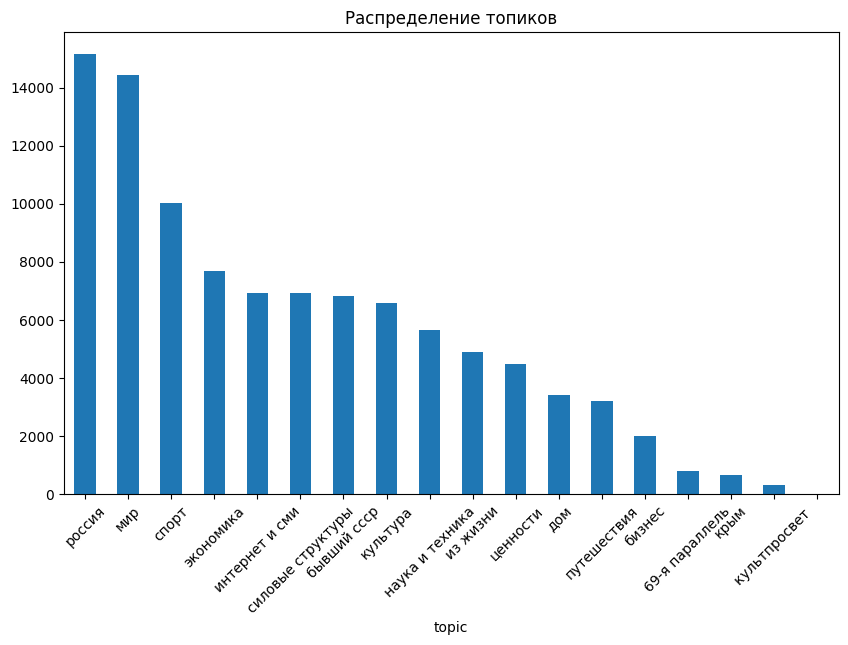

In [9]:
plt.figure(figsize=(10,6))
df_raw['topic'].value_counts().plot(kind='bar')
plt.title('Распределение топиков')
plt.xticks(rotation=45)
plt.show()

## Предобработка

In [10]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/semyon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding() # векторные представления слов, натренированные на новостях на русском языке
morph_tagger = NewsMorphTagger(emb)

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#### Пайплайн предобработки

1. Приводим к нижнему регистру
2. Оставляем только буквы
3. Используем word_tokenize

Убрал удаление стоп-слов, чтобы не ломать структуру предложений. Вместо этого стал использовать Subsampling при обучении.

In [12]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)
    tokens = word_tokenize(text, language='russian')
    return " ".join(tokens)

df_raw['cleaned_text'] = df_raw['text'].apply(preprocess_text)

In [13]:
df_raw.head()

,topic,text,cleaned_text
0,спорт,австрия не представила доказательств вины росс...,австрия не представила доказательств вины росс...
1,путешествия,обнаружено самое счастливое место на планете\n...,обнаружено самое счастливое место на планете с...
2,мир,в сша раскрыли сумму расходов на расследование...,в сша раскрыли сумму расходов на расследование...
3,мир,хакеры рассказали о планах великобритании зами...,хакеры рассказали о планах великобритании зами...
4,бывший ссср,архиепископ канонической упц отказался прийти ...,архиепископ канонической упц отказался прийти ...


In [14]:
df = df_raw[['topic']].copy()
df['text'] = df_raw['cleaned_text']
df.head()

,topic,text
0,спорт,австрия не представила доказательств вины росс...
1,путешествия,обнаружено самое счастливое место на планете с...
2,мир,в сша раскрыли сумму расходов на расследование...
3,мир,хакеры рассказали о планах великобритании зами...
4,бывший ссср,архиепископ канонической упц отказался прийти ...


In [15]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['topic'], test_size=0.4, stratify=df['topic'], random_state=random_state
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=random_state
)

print(f"Train: {len(train_texts)} ({len(train_texts)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_texts)} ({len(val_texts)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_texts)} ({len(test_texts)/len(df)*100:.1f}%)")

Train: 59997 (60.0%)
Val:   19999 (20.0%)
Test:  20000 (20.0%)


In [16]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(train_labels)
y_val_encoded = label_encoder.transform(val_labels)
y_test_encoded = label_encoder.transform(test_labels)

In [17]:
train_sentences = [text.split() for text in train_texts]

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=7,
    workers=4,
    negative=5, 
    sample=1e-4,
    sg=1,
    epochs=80
)

w2v_model.save("w2v_model.bin")

Размер вектора оставил по умолчанию.

Контекстное окно взял 7, чтобы была более асоциативная связь между словами.

Использовал Skip-gram т.к. он лучше справляется с аналогиями и редкими словами.

sample взял чуть больше стандартного, чтобы модель быстрее обучалась.

In [18]:
tests_most_similar = [
    'смертность',
    'селедка',
    'спорт',
    'доллар',
    'медицина'
]

for tem in tests_most_similar:
    try:
        print(w2v_model.wv.most_similar(tem, topn=5))
    except KeyError:
        print(f'Слово {tem} не найдено')

[('младенческая', 0.7319875359535217), ('смертности', 0.6722052097320557), ('смертей', 0.663975715637207), ('рождаемость', 0.6328876614570618), ('заболеваний', 0.6299611330032349)]
Слово селедка не найдено
[('экспресс', 0.7873320579528809), ('спортсмена', 0.7571150660514832), ('функционера', 0.7507439851760864), ('р', 0.7131126523017883), ('чемпионат', 0.6777406334877014)]
[('доллара', 0.8691335320472717), ('рубля', 0.8011887669563293), ('валюта', 0.7789934873580933), ('доллару', 0.7740541696548462), ('курс', 0.7637659907341003)]
[('патологию', 0.5393750071525574), ('современная', 0.5199151635169983), ('бюджетное', 0.5182673335075378), ('дефицитных', 0.5141797065734863), ('здравоохранение', 0.5033201575279236)]


In [19]:
print(w2v_model.wv.doesnt_match(['смертность', 'рак', 'онкология', 'термос']))

смертность


In [20]:
print(w2v_model.wv.doesnt_match(["рыба", "селедка", "ледник"]))

ледник


In [21]:
print(w2v_model.vector_size)

100


## Предобученные эмбединги

In [22]:
rusvectors_path = 'ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz'
navec_path = 'navec_news_v1_1B_250K_300d_100q.tar'

In [23]:
if not os.path.exists(navec_path):
    !wget https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar

In [24]:
if not os.path.exists(rusvectors_path):
    !wget "https://rusvectores.org/static/models/rusvectores4/ruwikiruscorpora/ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz"

In [25]:
navec_embeddings = navec.Navec.load(navec_path)

In [26]:
rusvectores_embeddings = gensim.models.KeyedVectors.load_word2vec_format(rusvectors_path)

## Обучение Логистической регрессии

In [27]:
def train_logistic_regression(X_train, X_val):
    model = LogisticRegression(max_iter=max_iter, random_state=random_state)
    model.fit(X_train, y_train_encoded)

    val_pred = model.predict(X_val)
    print("Validation Accuracy:", accuracy_score(y_val_encoded, val_pred))
    print(classification_report(y_val_encoded, val_pred))

    return model

#### Word2Vec

In [28]:
def text_to_vec(text, model):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return [0] * model.vector_size
    return np.mean(vectors, axis=0)

In [29]:
X_train_w2v = np.array([text_to_vec(text, w2v_model) for text in train_texts])
X_val_w2v = np.array([text_to_vec(text, w2v_model) for text in val_texts])
X_test_w2v = np.array([text_to_vec(text, w2v_model) for text in test_texts])

In [30]:
w2v_log_reg = train_logistic_regression(X_train_w2v, X_val_w2v)

Validation Accuracy: 0.7950897544877243
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.85      0.52      0.64       163
           2       0.58      0.33      0.42       399
           3       0.83      0.80      0.81      1362
           4       0.84      0.77      0.80       681
           5       0.73      0.73      0.73       980
           6       0.76      0.75      0.75      1387
           7       0.71      0.30      0.42       132
           8       0.61      0.23      0.33        62
           9       0.85      0.86      0.85      1315
          10       0.79      0.86      0.82      2884
          11       0.85      0.85      0.85      1129
          12       0.80      0.71      0.75       645
          13       0.71      0.79      0.75      3030
          14       0.72      0.66      0.69      1385
          15       0.96      0.96      0.96      2009
          16       0.90      0.85      0.

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/n

#### Navec

In [31]:
def text_to_vec_navec(text, navec_model):
    words = text.split()
    vectors = [navec_model[word] for word in words if word in navec_model]
    if len(vectors) == 0:
        return [0] * navec_model.vector_size
    return np.mean(vectors, axis=0)

In [32]:
X_train_navec = np.array([text_to_vec_navec(text, navec_embeddings) for text in train_texts])
X_val_navec = np.array([text_to_vec_navec(text, navec_embeddings) for text in val_texts])
X_test_navec = np.array([text_to_vec_navec(text, navec_embeddings) for text in test_texts])

In [33]:
navec_log_reg = train_logistic_regression(X_train_navec, X_val_navec)

Validation Accuracy: 0.7977898894944747
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.70      0.55      0.61       163
           2       0.55      0.41      0.47       399
           3       0.83      0.84      0.84      1362
           4       0.80      0.79      0.79       681
           5       0.72      0.72      0.72       980
           6       0.74      0.77      0.76      1387
           7       0.74      0.45      0.56       132
           8       0.66      0.37      0.47        62
           9       0.84      0.86      0.85      1315
          10       0.82      0.85      0.83      2884
          11       0.84      0.84      0.84      1129
          12       0.78      0.74      0.76       645
          13       0.75      0.76      0.75      3030
          14       0.70      0.68      0.69      1385
          15       0.96      0.96      0.96      2009
          16       0.89      0.85      0.

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/n

#### Rusvectores

In [34]:
def text_to_vec_rusvectores(text, model):
    words = text.split()
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return [0] * model.vector_size
    return np.mean(vectors, axis=0)

In [35]:
rusvectores_embeddings.most_similar(positive=['человек_NOUN'], topn=10)

[('людямя_NOUN', 0.6312709450721741),
 ('человек_PROPN', 0.6004737615585327),
 ('человекомя_NOUN', 0.6001946330070496),
 ('человеколо_NOUN', 0.5959703326225281),
 ('людей_NOUN', 0.572259783744812),
 ('человѣкъ_PROPN', 0.5592873692512512),
 ('чел[овек_NOUN', 0.538690984249115),
 ('человека_NOUN', 0.537072479724884),
 ('женщинута_NOUN', 0.5307294726371765),
 ('женщина_NOUN', 0.5291808843612671)]

In [36]:
X_train_rusvectores = np.array([text_to_vec_rusvectores(text, rusvectores_embeddings) for text in train_texts])
X_val_rusvectores = np.array([text_to_vec_rusvectores(text, rusvectores_embeddings) for text in val_texts])
X_test_rusvectores = np.array([text_to_vec_rusvectores(text, rusvectores_embeddings) for text in test_texts])

In [37]:
rusvectores_log_reg = train_logistic_regression(X_train_rusvectores, X_val_rusvectores)

Validation Accuracy: 0.15150757537876894
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00       163
           2       0.00      0.00      0.00       399
           3       0.00      0.00      0.00      1362
           4       0.00      0.00      0.00       681
           5       0.00      0.00      0.00       980
           6       0.00      0.00      0.00      1387
           7       0.00      0.00      0.00       132
           8       0.00      0.00      0.00        62
           9       0.00      0.00      0.00      1315
          10       0.00      0.00      0.00      2884
          11       0.00      0.00      0.00      1129
          12       0.00      0.00      0.00       645
          13       0.15      1.00      0.26      3030
          14       0.00      0.00      0.00      1385
          15       0.00      0.00      0.00      2009
          16       0.00      0.00      0

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Регрессия с обученным word2vec и navec показали очень похожие результаты. Rusvectores почему-то выдал очень низки значения.

### Лучший с TF-IDF

In [38]:
vectorizer = TfidfVectorizer()

In [39]:
X_train_tfidf_weights = vectorizer.fit_transform(train_texts)
X_val_tfidf_weights = vectorizer.transform(val_texts)

In [40]:
def get_weighted_navec_embedding(text, tfidf_weights):
    words = text.split()
    embeddings = []
    weights = []

    for word in words:
        if word in navec_embeddings:
            embeddings.append(navec_embeddings[word])
            try:
                word_index = vectorizer.vocabulary_[word]
                weight = tfidf_weights[0, word_index]
                weights.append(weight)
            except KeyError:
                weights.append(0)

    if embeddings and weights and sum(weights) != 0:
        return np.average(embeddings, axis=0, weights=weights)
    else:
        return np.zeros(navec_embeddings.pq.shape[0])

In [41]:
X_train_weighted_navec = np.array([get_weighted_navec_embedding(text, X_train_tfidf_weights[i]) for i, text in enumerate(train_texts)])
X_val_weighted_navec = np.array([get_weighted_navec_embedding(text, X_val_tfidf_weights[i]) for i, text in enumerate(val_texts)])

In [42]:
model_navec_weighted = LogisticRegression(random_state=random_state)
model_navec_weighted.fit(X_train_weighted_navec, y_train_encoded)

y_pred_weighted_navec = model_navec_weighted.predict(X_val_weighted_navec)

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
print(classification_report(y_val_encoded, y_pred_weighted_navec))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.74      0.53      0.62       163
           2       0.52      0.37      0.43       399
           3       0.83      0.83      0.83      1362
           4       0.78      0.77      0.77       681
           5       0.69      0.69      0.69       980
           6       0.74      0.72      0.73      1387
           7       0.68      0.51      0.58       132
           8       0.50      0.32      0.39        62
           9       0.83      0.83      0.83      1315
          10       0.79      0.84      0.82      2884
          11       0.81      0.83      0.82      1129
          12       0.75      0.72      0.74       645
          13       0.71      0.75      0.73      3030
          14       0.69      0.64      0.66      1385
          15       0.96      0.95      0.96      2009
          16       0.88      0.84      0.86       896
          17       0.75    

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

### Сравнение моделей на тестовой выборке

In [44]:
def test_model(model, X_test):
    test_pred = model.predict(X_test)
    print("Validation Accuracy:", accuracy_score(y_test_encoded, test_pred))
    print(classification_report(y_test_encoded, test_pred))

#### Word2Vec

In [45]:
test_model(w2v_log_reg, X_test_w2v)

Validation Accuracy: 0.79025
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.84      0.50      0.63       163
           2       0.54      0.30      0.39       398
           3       0.81      0.80      0.81      1362
           4       0.83      0.77      0.80       682
           5       0.73      0.74      0.73       981
           6       0.76      0.73      0.74      1387
           7       0.71      0.27      0.39       132
           8       0.59      0.21      0.31        61
           9       0.85      0.85      0.85      1316
          10       0.79      0.85      0.82      2885
          11       0.85      0.85      0.85      1129
          12       0.81      0.73      0.77       644
          13       0.70      0.77      0.73      3030
          14       0.72      0.68      0.70      1385
          15       0.96      0.96      0.96      2009
          16       0.90      0.88      0.89       89

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

#### Navec

In [46]:
test_model(navec_log_reg, X_test_navec)

Validation Accuracy: 0.7964
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.72      0.55      0.62       163
           2       0.50      0.36      0.42       398
           3       0.83      0.85      0.84      1362
           4       0.81      0.79      0.80       682
           5       0.72      0.72      0.72       981
           6       0.74      0.73      0.74      1387
           7       0.78      0.44      0.56       132
           8       0.51      0.33      0.40        61
           9       0.83      0.85      0.84      1316
          10       0.82      0.85      0.83      2885
          11       0.83      0.86      0.85      1129
          12       0.78      0.76      0.77       644
          13       0.74      0.75      0.75      3030
          14       0.71      0.70      0.70      1385
          15       0.96      0.96      0.96      2009
          16       0.89      0.88      0.88       896

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

#### Rusvectores

In [47]:
test_model(rusvectores_log_reg, X_test_rusvectores)

Validation Accuracy: 0.1515
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00       163
           2       0.00      0.00      0.00       398
           3       0.00      0.00      0.00      1362
           4       0.00      0.00      0.00       682
           5       0.00      0.00      0.00       981
           6       0.00      0.00      0.00      1387
           7       0.00      0.00      0.00       132
           8       0.00      0.00      0.00        61
           9       0.00      0.00      0.00      1316
          10       0.00      0.00      0.00      2885
          11       0.00      0.00      0.00      1129
          12       0.00      0.00      0.00       644
          13       0.15      1.00      0.26      3030
          14       0.00      0.00      0.00      1385
          15       0.00      0.00      0.00      2009
          16       0.00      0.00      0.00       896

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

#### TfIdf + Navec

In [48]:
X_test_tfidf_weights = vectorizer.transform(test_texts)
X_test_weighted_navec = np.array([get_weighted_navec_embedding(text, X_test_tfidf_weights[i]) for i, text in enumerate(test_texts)])

test_model(model_navec_weighted, X_test_weighted_navec)

Validation Accuracy: 0.7798
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.76      0.56      0.64       163
           2       0.50      0.32      0.39       398
           3       0.83      0.82      0.83      1362
           4       0.79      0.76      0.78       682
           5       0.68      0.69      0.69       981
           6       0.73      0.72      0.72      1387
           7       0.71      0.46      0.56       132
           8       0.57      0.28      0.37        61
           9       0.82      0.85      0.84      1316
          10       0.79      0.84      0.81      2885
          11       0.81      0.84      0.82      1129
          12       0.75      0.71      0.73       644
          13       0.72      0.75      0.73      3030
          14       0.71      0.67      0.69      1385
          15       0.96      0.95      0.95      2009
          16       0.88      0.85      0.86       896

/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/semyon/python_projects/NLP/nlp-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

### Выводы

Лучше всего логистическая регрессия показала себя с Navec, чуть хуже Word2Vec. TF-IDF с Navec показал результаты хуже, возможно, из-за переобучения. С Rusvectores почему-то получились очень плохие результаты.